In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,confusion_matrix,classification_report
import matplotlib as plt
import seaborn as sns
from glob import glob
import torch.nn as nn
import cv2
import torch
import torchvision
from torchvision.transforms import transforms
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

In [8]:
import tensorflow_datasets as tfds

dataset = tfds.load("cifar10", split="train", as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.BXLRAO_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.BXLRAO_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [9]:
for image, label in dataset.take(1):
    print(image.shape)  # (32, 32, 3)
    print(label)        # class index

(32, 32, 3)
tf.Tensor(7, shape=(), dtype=int64)


In [10]:
import tensorflow as tf

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

dataset = dataset.map(preprocess)
dataset = dataset.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)


In [11]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")



Torch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [12]:
if  torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [13]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [14]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the TensorFlow ResNet50 model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
tf_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Using the tf_resnet_model ensures we use the Keras compile method
model.compile(optimizer=tf_optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [37]:
model.fit(dataset, epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5876 - loss: 1.1922
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5998 - loss: 1.1577
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6122 - loss: 1.1266
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6225 - loss: 1.0992
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6310 - loss: 1.0725
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6396 - loss: 1.0508
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6465 - loss: 1.0304
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6534 - loss: 1.0089
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6601 - loss: 0.9897
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6661 - loss: 0.9721
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6714 - loss: 0.9563
Epoch 12/50
1563/1563 ━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6584 - loss: 1.0333

Test Accuracy: 0.6584

Classification Report:
              precision    recall  f1-score   support

       plane       0.70      0.68      0.69      1000
         car       0.80      0.73      0.76      1000
        bird       0.48      0.57      0.52      1000
         cat       0.53      0.38      0.44      1000
        deer       0.67      0.60      0.63      1000
         dog       0.55      0.58      0.57      1000
        frog       0.74      0.75      0.75      1000
       horse       0.73      0.71      0.72      1000
        ship       0.73      0.79      0.76      1000
       truck       0.66      0.80      0.72      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



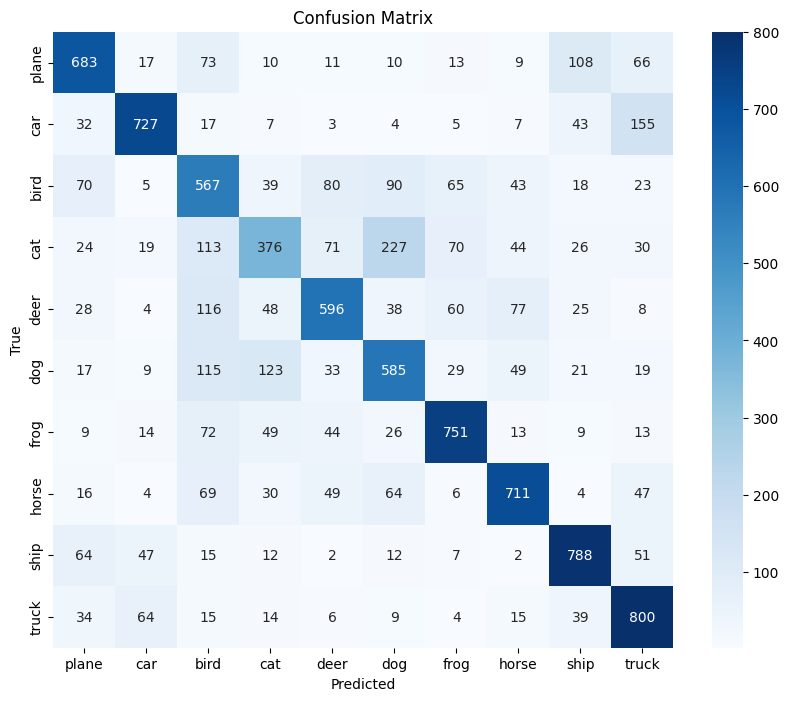

In [38]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Test Dataset
test_ds = tfds.load('cifar10', split='test', as_supervised=True)
test_ds = test_ds.map(preprocess).batch(32)

# 2. Evaluation (Test Accuracy)
loss, accuracy = model.evaluate(test_ds)
print(f'\nTest Accuracy: {accuracy:.4f}')

# 3. Predictions for Metrics
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 4. Classification Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

# 5. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [39]:
# 6. Save the model
model_save_path = 'cifar10_simple_cnn.h5'
model.save(model_save_path)
print(f'Model saved successfully to {model_save_path}')

Model saved successfully to cifar10_simple_cnn.h5


In [42]:
!pip install fastapi uvicorn pyngrok

In [43]:
from fastapi import FastAPI, File, UploadFile, HTTPException
from PIL import Image
import numpy as np
import tensorflow as tf
import io

app = FastAPI()

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

# Load model once (startup)
try:
    model = tf.keras.models.load_model("/content/cifar10_simple_cnn.h5")
except Exception as e:
    raise RuntimeError(f"Model loading failed: {e}")


def preprocess_image(image: Image.Image):
    image = image.resize((32, 32))  # CIFAR-10 size
    image = np.array(image)

    if image.shape[-1] != 3:
        raise ValueError("Image must be RGB")

    image = image / 255.0
    image = np.expand_dims(image, axis=0)
    return image


@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # ✅ Validate file type
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File must be an image")

    try:
        contents = await file.read()
        image = Image.open(io.BytesIO(contents)).convert("RGB")
    except Exception:
        raise HTTPException(status_code=400, detail="Invalid image file")

    try:
        processed = preprocess_image(image)
        preds = model.predict(processed)

        class_idx = int(np.argmax(preds[0]))
        confidence = float(np.max(preds[0]))

        return {
            "class": CLASS_NAMES[class_idx],
            "confidence": round(confidence, 4)
        }

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))